# Two-Tower Model Intro

## Роль notebook

Этот notebook должен показать уже не просто новую модель, а новую стадию рекомендательной системы: `retrieval`.
Здесь мы сравниваем `two-tower` retrieval с `popularity baseline` на text-rich датасете и отдельно проговариваем, чем retrieval отличается от final ranking.


## Методическая рамка

В `ALS`, `LightFM` и `NeuMF` мы в основном думали о том, насколько хорошо модель оценивает пару `user-item`.

В `two-tower` постановка другая:

- нам нужно быстро получить разумных кандидатов из большого каталога;
- user и item кодируются отдельно;
- итоговый score чаще используется как retrieval-score, а не как финальный ranking score для выдачи пользователю.

Здесь учебная цель не в том, чтобы построить production retrieval stack, а в том, чтобы понять саму идею двух башен.


## Почему меняем датасет

До этого `MovieLens` был удобен: он хорошо подходит для `ALS`, `LightFM`, `NeuMF`, где основной сигнал — это `user-item` interactions. Там мы учились сравнивать collaborative / hybrid / neural scoring модели в одной и той же offline-постановке.

Для `two-tower` задача другая: показать `retrieval`, где user и item кодируются отдельно и модель ищет кандидатов по близости embedding'ов. Чтобы это было наглядно, нужны богатые item-признаки. В `MovieLens latest small` таких признаков мало: по сути `title`, `genres`, немного `tags`. На `Amazon Reviews 2023 / All_Beauty` есть более естественный text-rich сценарий: `titles`, `descriptions`, `features`, `categories`, `store`. Поэтому user/item text-представления там имеют учебный смысл.


## План

- один раз скачать `Amazon Reviews 2023 / All_Beauty` в локальный `data/raw/amazon_reviews_2023`;
- работать уже с локально сохранёнными файлами, без повторной сетевой загрузки в каждом notebook;
- подготовить компактный воспроизводимый slice;
- сохранить `train / validation / test` с временной логикой на пользователя;
- построить text-based item features и user history profiles;
- обучить учебную `two-tower` retrieval модель на `PyTorch`;
- сравнить её хотя бы с `popularity baseline`;
- отдельно зафиксировать границу: retrieval ещё не равен final ranking.


## Требования к окружению

Этот notebook работает с локально сохранёнными файлами `Amazon Reviews 2023 / All_Beauty`.

Ожидаемая директория:

- `data/raw/amazon_reviews_2023/All_Beauty.jsonl`
- `data/raw/amazon_reviews_2023/meta_All_Beauty.jsonl`

Нужная библиотека для самого notebook:

- `torch`

Если локальных файлов ещё нет, их нужно один раз скачать в `data/raw`, а дальше следующие notebook'и будут читать уже сохранённые файлы.


In [1]:
import os

os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


def find_project_root(start_path: Path) -> Path:
    for candidate in [start_path, *start_path.parents]:
        if (candidate / "src" / "recsys_basics").exists():
            return candidate
    raise FileNotFoundError("Не удалось найти корень проекта с папкой src/recsys_basics")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.style.use("ggplot")

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"SRC_DIR: {SRC_DIR}")


PROJECT_ROOT: /Users/bobrsubr/PycharmProjects/_researches/recommender-systems-from-zero
SRC_DIR: /Users/bobrsubr/PycharmProjects/_researches/recommender-systems-from-zero/src


In [2]:
# Скачайте датасет один раз. Эта ячейка специально reload'ит модуль,
# чтобы Jupyter не держал старую версию downloader после правок в src/.
# import importlib
# import recsys_basics.data as data_module
#
# data_module = importlib.reload(data_module)
# print("Download URLs:")
# print("\n".join(data_module.get_amazon_reviews_2023_download_urls("All_Beauty")))
#
# data_module.download_amazon_reviews_2023_files(category="All_Beauty")


Download URLs:
https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/review_categories/All_Beauty.jsonl.gz
https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/meta_categories/meta_All_Beauty.jsonl.gz


(PosixPath('/Users/bobrsubr/PycharmProjects/_researches/recommender-systems-from-zero/data/raw/amazon_reviews_2023/All_Beauty.jsonl'),
 PosixPath('/Users/bobrsubr/PycharmProjects/_researches/recommender-systems-from-zero/data/raw/amazon_reviews_2023/meta_All_Beauty.jsonl'))

In [3]:
try:
    import torch
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "Библиотека `torch` не установлена. Установите её в окружение проекта (`pip install torch`) и перезапустите notebook."
    ) from exc

from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import Normalizer

from recsys_basics.advanced.two_tower import TwoTowerRetrievalRecommender, build_user_text_profiles
from recsys_basics.basic.popularity import (
    PopularityRecommender,
    build_seen_items_map,
    filter_positive_explicit_feedback,
)
from recsys_basics.data import (
    get_amazon_reviews_2023_data_dir,
    load_amazon_reviews_2023_frames,
    prepare_amazon_item_metadata,
    build_amazon_reviews_interactions,
)
from recsys_basics.metrics import evaluate_ranking_metrics
from recsys_basics.split import assert_no_user_time_leakage, leave_last_two_out_split

CATEGORY = "All_Beauty"
DATA_DIR = get_amazon_reviews_2023_data_dir()
MIN_RATING = 4.0
TOP_K = 10

frames = load_amazon_reviews_2023_frames(category=CATEGORY, data_dir=DATA_DIR)

interactions_df = build_amazon_reviews_interactions(frames.reviews)
item_metadata_df = prepare_amazon_item_metadata(frames.metadata)
item_metadata_df["item_id"] = item_metadata_df["item_id"].astype(str)
item_metadata_df["item_text"] = item_metadata_df["item_text"].fillna("").astype(str)
empty_mask = item_metadata_df["item_text"].str.strip() == ""
item_metadata_df.loc[empty_mask, "item_text"] = item_metadata_df.loc[empty_mask, "title"].fillna("").astype(str)

print(f"Amazon category: {CATEGORY}")
print(f"Local data dir: {DATA_DIR}")
print(f"Raw interactions loaded: {len(interactions_df):,}")
print(f"Metadata rows loaded: {len(item_metadata_df):,}")
print(f"Torch version: {torch.__version__}")


Amazon category: All_Beauty
Local data dir: /Users/bobrsubr/PycharmProjects/_researches/recommender-systems-from-zero/data/raw/amazon_reviews_2023
Raw interactions loaded: 701,528
Metadata rows loaded: 112,590
Torch version: 2.12.0


In [4]:
def deduplicate_keep_last(interactions: pd.DataFrame) -> pd.DataFrame:
    ordered = interactions.sort_values(["user_id", "item_id", "timestamp"])
    return ordered.drop_duplicates(["user_id", "item_id"], keep="last").reset_index(drop=True)


def iterative_k_core(
    interactions: pd.DataFrame,
    min_user_interactions: int = 3,
    min_item_interactions: int = 3,
    max_rounds: int = 10,
) -> pd.DataFrame:
    current = interactions.copy()
    for _ in range(max_rounds):
        before_len = len(current)
        user_counts = current.groupby("user_id").size()
        item_counts = current.groupby("item_id").size()
        current = current[current["user_id"].isin(user_counts[user_counts >= min_user_interactions].index)]
        current = current[current["item_id"].isin(item_counts[item_counts >= min_item_interactions].index)]
        current = current.reset_index(drop=True)
        if len(current) == before_len:
            break
    return current


def make_compact_slice(
    interactions: pd.DataFrame,
    max_users: int = 2000,
    max_items: int = 2500,
    min_user_interactions: int = 3,
    min_item_interactions: int = 3,
) -> pd.DataFrame:
    working = deduplicate_keep_last(interactions)
    working = iterative_k_core(
        working,
        min_user_interactions=min_user_interactions,
        min_item_interactions=min_item_interactions,
    )

    top_users = (
        working.groupby("user_id")
        .size()
        .sort_values(ascending=False)
        .head(max_users)
        .index
    )
    working = working[working["user_id"].isin(top_users)].copy()

    top_items = (
        working.groupby("item_id")
        .size()
        .sort_values(ascending=False)
        .head(max_items)
        .index
    )
    working = working[working["item_id"].isin(top_items)].copy()
    working = iterative_k_core(
        working,
        min_user_interactions=min_user_interactions,
        min_item_interactions=min_item_interactions,
    )
    return working.sort_values(["timestamp", "user_id", "item_id"]).reset_index(drop=True)


positive_df = filter_positive_explicit_feedback(interactions_df, min_rating=MIN_RATING)
positive_df["user_id"] = positive_df["user_id"].astype(str)
positive_df["item_id"] = positive_df["item_id"].astype(str)
positive_df = make_compact_slice(positive_df)
item_metadata_df = item_metadata_df[item_metadata_df["item_id"].isin(positive_df["item_id"].unique())].copy()

slice_summary = pd.DataFrame(
    {
        "metric": [
            "positive_rows_after_slice",
            "users_after_slice",
            "items_after_slice",
            "metadata_items_matched",
        ],
        "value": [
            len(positive_df),
            positive_df["user_id"].nunique(),
            positive_df["item_id"].nunique(),
            item_metadata_df["item_id"].nunique(),
        ],
    }
)

display(slice_summary)
positive_df.head()


,metric,value
0,positive_rows_after_slice,6490
1,users_after_slice,971
2,items_after_slice,1173
3,metadata_items_matched,1173


,user_id,item_id,rating,timestamp,event
0,AEHOFUNZP6VT74RUDDCJ2VVIT56A,B002C741NG,4.0000,2009-08-09 18:19:06+00:00,positive_rating
1,AEYERBW72D3BWUI4EVNBONPQWQYQ,B002C741NG,5.0000,2009-08-12 19:13:45+00:00,positive_rating
2,AE6AUO3Z6Q5N5VK2JDWGZEGFW4GA,B002C741NG,4.0000,2009-08-27 13:30:34+00:00,positive_rating
3,AFWVN52MRBWOTIK7UGXBWGOY4HBA,B007VXJK6E,5.0000,2012-07-17 23:37:11+00:00,positive_rating
4,AEFDIVNWWBP2IEEPXCTIRWCIPWSA,B007VXJK6E,5.0000,2012-09-10 23:10:51+00:00,positive_rating


In [5]:
split_result = leave_last_two_out_split(positive_df, min_user_interactions=3)
train_df = split_result.train.copy()
val_df = split_result.validation.copy()
test_df = split_result.test.copy()

assert_no_user_time_leakage(train_df, val_df)
assert_no_user_time_leakage(pd.concat([train_df, val_df], ignore_index=True), test_df)

train_item_ids = set(train_df["item_id"].unique().tolist())
val_new_item_share = float((~val_df["item_id"].isin(train_item_ids)).mean())
test_new_item_share = float((~test_df["item_id"].isin(train_item_ids)).mean())

split_summary = pd.DataFrame(
    {
        "metric": [
            "train_rows",
            "validation_rows",
            "test_rows",
            "train_users",
            "validation_users",
            "test_users",
            "train_items",
            "validation_items",
            "test_items",
            "validation_new_item_share_vs_train",
            "test_new_item_share_vs_train",
        ],
        "value": [
            len(train_df),
            len(val_df),
            len(test_df),
            train_df["user_id"].nunique(),
            val_df["user_id"].nunique(),
            test_df["user_id"].nunique(),
            train_df["item_id"].nunique(),
            val_df["item_id"].nunique(),
            test_df["item_id"].nunique(),
            val_new_item_share,
            test_new_item_share,
        ],
    }
)

display(split_summary)


,metric,value
0,train_rows,"4,548.0000"
1,validation_rows,971.0000
2,test_rows,971.0000
3,train_users,971.0000
4,validation_users,971.0000
5,test_users,971.0000
6,train_items,"1,128.0000"
7,validation_items,618.0000
8,test_items,569.0000
9,validation_new_item_share_vs_train,0.0690


Здесь `train / validation / test` делятся не по фиксированным процентам, а по временной логике на пользователя: одно предпоследнее positive interaction идёт в `validation`, одно последнее в `test`, а вся более ранняя история остаётся в `train`.

Поэтому `validation` и `test` здесь маленькие по числу строк, но это нормально: их задача не занять красивый процент датасета, а дать по одному честному отложенному примеру на каждого пользователя.

Отдельно важно смотреть на `validation_new_item_share_vs_train` и `test_new_item_share_vs_train`: completely new items retrieval-модель из train просто не знает, и это честное ограничение постановки.


In [6]:
def project_text_corpus(
    ids: pd.Series,
    texts: pd.Series,
    prefix: str,
    max_features: int = 4000,
    n_components: int = 64,
) -> tuple[pd.DataFrame, dict[str, int | float]]:
    vectorizer = TfidfVectorizer(
        max_features=max_features,
        min_df=2,
        ngram_range=(1, 2),
        stop_words="english",
    )
    tfidf = vectorizer.fit_transform(texts.fillna("").astype(str))
    if tfidf.shape[1] == 0:
        raise ValueError(f"После vectorization для {prefix} не осталось признаков")

    effective_components = min(
        n_components,
        max(1, tfidf.shape[0] - 1),
        max(1, tfidf.shape[1] - 1),
    )
    if effective_components >= 2:
        projector = TruncatedSVD(n_components=effective_components, random_state=42)
        dense = projector.fit_transform(tfidf)
        explained_variance = float(projector.explained_variance_ratio_.sum())
    else:
        dense = tfidf.toarray().astype("float32")
        effective_components = dense.shape[1]
        explained_variance = 1.0

    normalizer = Normalizer(copy=False)
    dense = normalizer.fit_transform(dense)

    feature_columns = [f"{prefix}_{index:03d}" for index in range(dense.shape[1])]
    features_df = pd.DataFrame(dense, columns=feature_columns)
    features_df.insert(0, "entity_id", ids.tolist())
    return features_df, {
        "rows": int(tfidf.shape[0]),
        "raw_tfidf_features": int(tfidf.shape[1]),
        "projected_features": int(dense.shape[1]),
        "explained_variance": explained_variance,
    }


train_item_catalog_df = (
    item_metadata_df[item_metadata_df["item_id"].isin(sorted(train_df["item_id"].unique().tolist()))]
    .drop_duplicates(subset=["item_id"])
    .copy()
)
train_item_catalog_df["item_text"] = train_item_catalog_df["item_text"].fillna("").astype(str)
empty_item_mask = train_item_catalog_df["item_text"].str.strip() == ""
train_item_catalog_df.loc[empty_item_mask, "item_text"] = (
    train_item_catalog_df.loc[empty_item_mask, "title"].fillna("").astype(str)
)

user_profiles_df = build_user_text_profiles(
    train_df,
    train_item_catalog_df[["item_id", "item_text"]],
    max_history_items=15,
)
all_train_users_df = pd.DataFrame({"user_id": sorted(train_df["user_id"].unique().tolist())})
user_profiles_df = all_train_users_df.merge(user_profiles_df, on="user_id", how="left")
user_profiles_df["user_text"] = user_profiles_df["user_text"].fillna("unknown user history")
user_profiles_df["history_items"] = user_profiles_df["history_items"].fillna(0).astype(int)

item_features_df, item_feature_stats = project_text_corpus(
    ids=train_item_catalog_df["item_id"],
    texts=train_item_catalog_df["item_text"],
    prefix="item_feature",
)
item_features_df = item_features_df.rename(columns={"entity_id": "item_id"})

user_features_df, user_feature_stats = project_text_corpus(
    ids=user_profiles_df["user_id"],
    texts=user_profiles_df["user_text"],
    prefix="user_feature",
)
user_features_df = user_features_df.rename(columns={"entity_id": "user_id"})

feature_summary = pd.DataFrame(
    [
        {"block": "item_text", **item_feature_stats},
        {"block": "user_history_text", **user_feature_stats},
    ]
)

display(feature_summary)
feature_summary


,block,rows,raw_tfidf_features,projected_features,explained_variance
0,item_text,1128,4000,64,0.3065
1,user_history_text,971,4000,64,0.4338


,block,rows,raw_tfidf_features,projected_features,explained_variance
0,item_text,1128,4000,64,0.3065
1,user_history_text,971,4000,64,0.4338


In [7]:
seen_items_map = build_seen_items_map(train_df)
val_user_ids = sorted(val_df["user_id"].unique().tolist())
test_user_ids = sorted(test_df["user_id"].unique().tolist())

TWOTOWER_CONFIG = {
    "embedding_dim": 32,
    "hidden_dims": (64,),
    "dropout": 0.0,
    "num_epochs": 12,
    "batch_size": 1024,
    "learning_rate": 1e-3,
    "weight_decay": 1e-5,
    "num_negatives": 4,
}

popularity_model = PopularityRecommender().fit(train_df)
two_tower_model = TwoTowerRetrievalRecommender(
    embedding_dim=TWOTOWER_CONFIG["embedding_dim"],
    hidden_dims=TWOTOWER_CONFIG["hidden_dims"],
    dropout=TWOTOWER_CONFIG["dropout"],
    num_epochs=TWOTOWER_CONFIG["num_epochs"],
    batch_size=TWOTOWER_CONFIG["batch_size"],
    learning_rate=TWOTOWER_CONFIG["learning_rate"],
    weight_decay=TWOTOWER_CONFIG["weight_decay"],
    num_negatives=TWOTOWER_CONFIG["num_negatives"],
    random_state=42,
).fit(
    train_df,
    user_features=user_features_df,
    item_features=item_features_df,
)

config_summary = pd.DataFrame(
    {
        "metric": [
            "item_feature_dims",
            "user_feature_dims",
            "embedding_dim",
            "hidden_dims",
            "num_epochs",
            "num_negatives",
            "final_train_loss",
        ],
        "value": [
            item_features_df.shape[1] - 1,
            user_features_df.shape[1] - 1,
            TWOTOWER_CONFIG["embedding_dim"],
            str(TWOTOWER_CONFIG["hidden_dims"]),
            TWOTOWER_CONFIG["num_epochs"],
            TWOTOWER_CONFIG["num_negatives"],
            two_tower_model.train_loss_history_[-1],
        ],
    }
)

display(config_summary)


,metric,value
0,item_feature_dims,64
1,user_feature_dims,64
2,embedding_dim,32
3,hidden_dims,"(64,)"
4,num_epochs,12
5,num_negatives,4
6,final_train_loss,0.4892


In [8]:
item_title_map = (
    item_metadata_df[["item_id", "title"]]
    .drop_duplicates(subset=["item_id"])
    .set_index("item_id")["title"]
    .to_dict()
)

sample_user_id = val_user_ids[0]
sample_validation_item = val_df.loc[val_df["user_id"] == sample_user_id, "item_id"].iloc[0]
sample_recommendations = two_tower_model.recommend(
    user_id=sample_user_id,
    seen_items=seen_items_map.get(sample_user_id, set()),
    k=TOP_K,
)

sample_df = pd.DataFrame(
    {
        "rank": range(1, len(sample_recommendations) + 1),
        "item_id": sample_recommendations,
        "title": [item_title_map.get(item_id, "<missing title>") for item_id in sample_recommendations],
    }
)

print(f"Sample validation user_id: {sample_user_id}")
print(
    "Validation target item:",
    sample_validation_item,
    "|",
    item_title_map.get(sample_validation_item, "<missing title>"),
)
display(sample_df)


Sample validation user_id: AE22XHMBOBJBXUFCTNYLFMD4UKMA
Validation target item: B00OS9YWJY | Pure Hyaluronic Acid Serum with Vitamin C for Face - Organic Anti Aging & Anti-Wrinkle Skin Treatment - Penetrates Deeply & Activates Collagen Production for a Younger, Firmer & Brighter Complexion


,rank,item_id,title
0,1,B00PKIE760,InstaNatural Cellulite Cream - With Caffeine &...
1,2,B08W2HG4BD,isavera Anti-Cellulite Cream with Aloe Vera an...
2,3,B00O3ILA5Y,Mother’s Select Stretchmark & Cellulite Comple...
3,4,B00OPEASFO,Professional Grade Retinol Anti-Aging Skin Moi...
4,5,B0977LVHF8,YERMA Makeup Face Primer with Brush - Instant ...
5,6,B00VXEQ0WO,Retinol 2.5% Cream From Majestic Pure for Face...
6,7,B09Z354HDV,Hygieia + Encapsulated 2% Retinol Cream – Lipo...
7,8,B08P2DZB4X,NIRA Skincare Laser & Serum Bundle - Includes ...
8,9,B09GGVH7RQ,Auntie & Me Liquid Gold Organic Anti-Aging Fac...
9,10,B00TKKMIRO,"Nunutrients Facelift Anti Aging Serum, Can be ..."


In [9]:
popularity_val_recs = popularity_model.recommend_many(val_user_ids, seen_items_map=seen_items_map, k=TOP_K)
popularity_test_recs = popularity_model.recommend_many(test_user_ids, seen_items_map=seen_items_map, k=TOP_K)

two_tower_val_recs = two_tower_model.recommend_many(val_user_ids, seen_items_map=seen_items_map, k=TOP_K)
two_tower_test_recs = two_tower_model.recommend_many(test_user_ids, seen_items_map=seen_items_map, k=TOP_K)

print(f"Popularity validation rec rows: {len(popularity_val_recs):,}")
print(f"Two-tower validation rec rows: {len(two_tower_val_recs):,}")


Popularity validation rec rows: 9,710
Two-tower validation rec rows: 9,710


In [10]:
def summarize_metrics(
    eval_df: pd.DataFrame,
    recommendations: pd.DataFrame,
    name: str,
    k: int = TOP_K,
) -> dict[str, float | str]:
    metrics_df = evaluate_ranking_metrics(eval_df, recommendations, k=k)
    unique_items = recommendations["item_id"].nunique() if not recommendations.empty else 0
    catalog_items = train_df["item_id"].nunique()
    summary = {"model": name}
    for column in metrics_df.columns:
        if column == "user_id":
            continue
        summary[column] = float(metrics_df[column].mean())
    summary["catalog_coverage"] = unique_items / catalog_items if catalog_items else 0.0
    summary["unique_recommended_items"] = int(unique_items)
    return summary


validation_comparison = pd.DataFrame(
    [
        summarize_metrics(val_df, popularity_val_recs, "popularity"),
        summarize_metrics(val_df, two_tower_val_recs, "two_tower"),
    ]
)

test_comparison = pd.DataFrame(
    [
        summarize_metrics(test_df, popularity_test_recs, "popularity"),
        summarize_metrics(test_df, two_tower_test_recs, "two_tower"),
    ]
)

print("Validation comparison:")
display(validation_comparison)
print("Held-out test comparison:")
display(test_comparison)


Validation comparison:


,model,precision@10,recall@10,hit_rate@10,map@10,ndcg@10,catalog_coverage,unique_recommended_items
0,popularity,0.0018,0.0175,0.0175,0.0045,0.0075,0.0133,15
1,two_tower,0.0045,0.0453,0.0453,0.0167,0.0234,0.9743,1099


Held-out test comparison:


,model,precision@10,recall@10,hit_rate@10,map@10,ndcg@10,catalog_coverage,unique_recommended_items
0,popularity,0.0015,0.0154,0.0154,0.0047,0.0073,0.0133,15
1,two_tower,0.0035,0.0350,0.0350,0.0111,0.0167,0.9743,1099


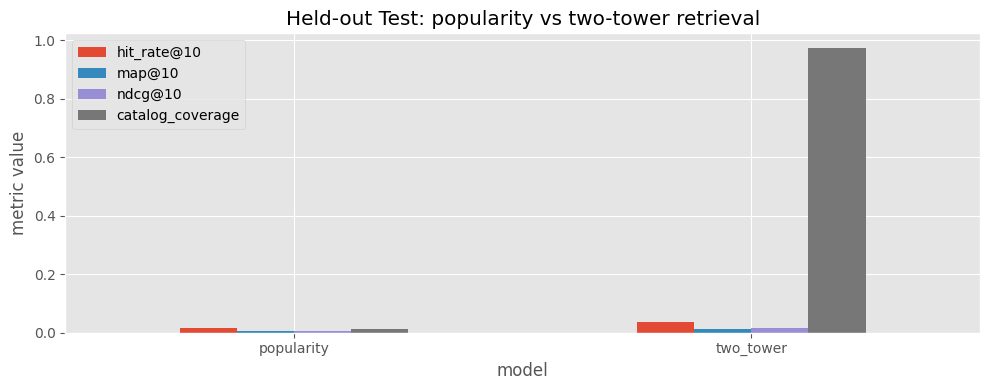

In [11]:
plot_df = test_comparison.set_index("model")[["hit_rate@10", "map@10", "ndcg@10", "catalog_coverage"]]
ax = plot_df.plot(kind="bar", figsize=(10, 4), rot=0)
ax.set_title("Held-out Test: popularity vs two-tower retrieval")
ax.set_ylabel("metric value")
plt.tight_layout()
plt.show()


## Как интерпретировать результат

В этом прогоне `two_tower` уверенно обыгрывает `popularity baseline` и на `validation`, и на held-out `test`.

На `test` результат такой:

- `hit_rate@10`: `0.0350` против `0.0154` у `popularity`;
- `MAP@10`: `0.0111` против `0.0047`;
- `NDCG@10`: `0.0167` против `0.0073`;
- `catalog_coverage`: `0.9743` против `0.0133`.

Главный учебный вывод здесь не в том, что модель уже сильная в абсолютном смысле. Абсолютные ranking-метрики пока низкие: один отложенный relevant item на пользователя, небольшой train-срез и простые text-features делают задачу шумной.

Важнее другое:

- `two-tower` использует user/item text-представления и находит более разнообразный candidate set, чем popularity;
- почти полный `catalog_coverage` показывает, что retrieval-модель не сводится к рекомендации одних и тех же популярных товаров;
- прирост по `MAP@10` и `NDCG@10` означает, что расширение coverage не произошло совсем вслепую: релевантные товары стали попадать выше чаще, чем у baseline.

Но ограничения остаются существенными:

- модель рекомендует только из train-каталога;
- `validation_new_item_share_vs_train = 0.0690`, а `test_new_item_share_vs_train = 0.1318`, поэтому часть отложенных товаров вообще недоступна для retrieval из train-каталога;
- retrieval здесь ещё не final ranking: в реальной системе такой `two-tower` скорее отдаёт кандидатов следующей ranking-стадии, а не формирует финальную выдачу сам по себе.


## Что дальше

Следующий шаг в маршруте: [04_sequence_recommender_intro.ipynb](04_sequence_recommender_intro.ipynb).
